# personal-cgm-lab - UCB Capstone - Exploratory Data Analysis

This notebook is the bridge between the raw data and the modeling notebooks. Every plot should either confirm a feature is worth including, or surface that I need to handle it before fitting.

**After initial analysis, switched daily features to a 4 AM physiological-day boundary** so overnight fasts don't split across midnight, **plus a fast-vs-feeding window decomposition** so the intermittent fasting effect can be measured cleanly without the calendar-day blur.

**Goals (from the capstone proposal):**

1. Walk ROI (25 vs 45 min): confounded by selection bias - I want to quantify that here.
2. Dinner given lunch: look for sequential meal dependencies.
3. Stable vs spiky meals: per-dish ranking with confidence intervals.
4. Daily mean toward A1C 6.0: daily trend + stationarity check for SARIMAX.

## 1. Setup

In [50]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller 
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (10, 5)

DATA_DIR        = os.path.abspath(os.path.join('..', 'data/processed'))
DATA_DIR_RAW    = os.path.abspath(os.path.join('..', 'data/raw'))

per_meal = pd.read_csv(os.path.join(DATA_DIR, 'per_meal_features.csv'), parse_dates=['ts', 'date'])
daily    = pd.read_csv(os.path.join(DATA_DIR, 'daily_features.csv'), parse_dates=['date'])

print(f"per_meal: {per_meal.shape}")
print(f"daily:    {daily.shape}")


per_meal: (295, 39)
daily:    (84, 36)


## 2. Data quality check

Before any analysis: duplicates, missing value coverage, and outlier boundaries. This is on the processed feature matrices (output of `00-build-features.py`), not the raw CSVs.

In [68]:
# ── Duplicates ───────────────────────────────────────────────────────────────
print("=== Duplicate check ===")
print(f"per_meal duplicate meal_id rows : {per_meal['meal_id'].duplicated().sum()}")
print(f"per_meal duplicate ts rows      : {per_meal['ts'].duplicated().sum()}")
print(f"daily duplicate date rows       : {daily['date'].duplicated().sum()}")

# ── Missing value summary ─────────────────────────────────────────────────────
print("\n=== Missing values (per_meal) — columns with any nulls ===")
null_pm = per_meal.isnull().sum()
print(null_pm[null_pm > 0].to_string())

print("\n=== Missing values (daily) — columns with any nulls ===")
null_d = daily.isnull().sum()
print(null_d[null_d > 0].to_string())

# ── Outlier analysis — IQR method ─────────────────────────────────────────────
print("\n=== Outlier analysis (IQR, 1.5x fence) ===")
for label, series in [
    ('peak_delta',    per_meal['peak_delta']),
    ('pre_meal_glucose', per_meal['pre_meal_glucose']),
    ('carbs_g_final', per_meal['carbs_g_final'].dropna()),
    ('cgm glucose_mg_dl', pd.read_csv(
        os.path.join(DATA_DIR_RAW, 'cgm_5min.csv'))['glucose_mg_dl'].dropna()),
]:
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((series < lo) | (series > hi)).sum()
    print(f"  {label:28s}  range [{series.min():.0f}, {series.max():.0f}]"
          f"  fence [{lo:.0f}, {hi:.0f}]  outliers: {n_out} / {len(series)}"
          f"  ({100*n_out/len(series):.1f}%)")

=== Duplicate check ===
per_meal duplicate meal_id rows : 0
per_meal duplicate ts rows      : 0
daily duplicate date rows       : 0

=== Missing values (per_meal) — columns with any nulls ===
dish_names                    13
food_match                    23
glucose_30min_before_mean      1
glucose_60min_before_mean      1
glucose_velocity_30min         9
carbs_g_final                 10
carbs_grams_logged           263
carbs_grams_estimated        295
carbs_g_lookup                23
protein_g_lookup              23
fat_g_lookup                  23
gl_lookup                     23
minutes_to_first_walk        262

=== Missing values (daily) — columns with any nulls ===
feeding_window_mean_glucose         1
feeding_window_tir_pct              1
feeding_window_n_readings           1
if_duration_hours                  70
mean_glucose_lag1                   1
mean_glucose_7d_avg_prior           3
mean_glucose_7d_avg_descriptive     2
total_walk_min_lag1                 1
total_carbs_lag1  

**Data quality notes:**

- No duplicate meal IDs or timestamps are expected. The build script uses the `meal_id` primary key from `meals_v2.csv` and there is no merge step that could fan out rows.
- Missing values in nutrition columns (`carbs_g_final`, `protein_g_lookup`, etc.) are structurally expected — not every meal was labeled with a dish name, and not every dish name matched the food lookup table. These are handled by median imputation inside the sklearn pipeline in the modeling notebook, fitted only on training data.
- CGM glucose outliers at the high end are real physiological events, not sensor errors. The Stelo sensor range is 70–250 mg/dL; readings near the ceiling are genuine hyperglycemic episodes and should be retained. I am not removing them.

In [51]:
per_meal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 295 entries, 0 to 294
Data columns (total 39 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   meal_id                       295 non-null    object        
 1   ts                            295 non-null    datetime64[ns]
 2   date                          295 non-null    datetime64[ns]
 3   dow                           295 non-null    object        
 4   time_bucket                   295 non-null    object        
 5   meal_type                     295 non-null    object        
 6   dish_names                    282 non-null    object        
 7   food_match                    272 non-null    object        
 8   peak_delta                    295 non-null    int64         
 9   peak_glucose                  295 non-null    int64         
 10  time_to_peak_min              295 non-null    int64         
 11  out_of_range_180              29

In [67]:
per_meal.sample(3, random_state=41)

,meal_id,ts,date,dow,time_bucket,meal_type,dish_names,food_match,peak_delta,peak_glucose,...,minutes_since_last_glipizide,broke_if_window,broke_window_type,prev_fast_hours,hour,hour_sin,hour_cos,is_weekend,day_index,walked_after
190,M0216,2026-03-31 06:20:43,2026-03-31,Tuesday,morning,tea,chai_with_milk_no_sugar,chai_with_milk_no_sugar,49,182,...,860.716667,False,overnight,12.0,6,1.000000,6.123234e-17,0,58,0
51,M0062,2026-02-16 02:02:41,2026-02-16,Monday,night,tea,cake,cake,88,159,...,602.683333,False,overnight,12.0,2,0.500000,8.660254e-01,0,15,0
123,M0140,2026-03-07 13:31:00,2026-03-07,Saturday,midday,lunch,NaN,NaN,84,209,...,211.000000,False,overnight,12.0,13,-0.258819,-9.659258e-01,1,34,0


## 2. Daily-level glucose overview

Anchored on the physio-day mean (4 AM). Will keep `mean_glucose_calendar` for endocrinologist-comparable reporting.

In [53]:
print(daily[['mean_glucose', 'mean_glucose_calendar', 'time_in_range_pct', 'gmi_estimate']].describe().round(2))
print(f"\nA1C 6.0 target: GMI ~6.0, mean glucose ~125, TIR > 70%")

       mean_glucose  mean_glucose_calendar  time_in_range_pct  gmi_estimate
count         84.00                  84.00              84.00         84.00
mean         175.01                 175.85              57.09          7.50
std           19.30                  20.95              17.07          0.46
min          136.09                 133.09              14.10          6.57
25%          161.22                 161.85              44.25          7.16
50%          174.84                 175.20              58.00          7.49
75%          186.49                 187.48              68.35          7.77
max          214.45                 226.56              96.20          8.44

A1C 6.0 target: GMI ~6.0, mean glucose ~125, TIR > 70%


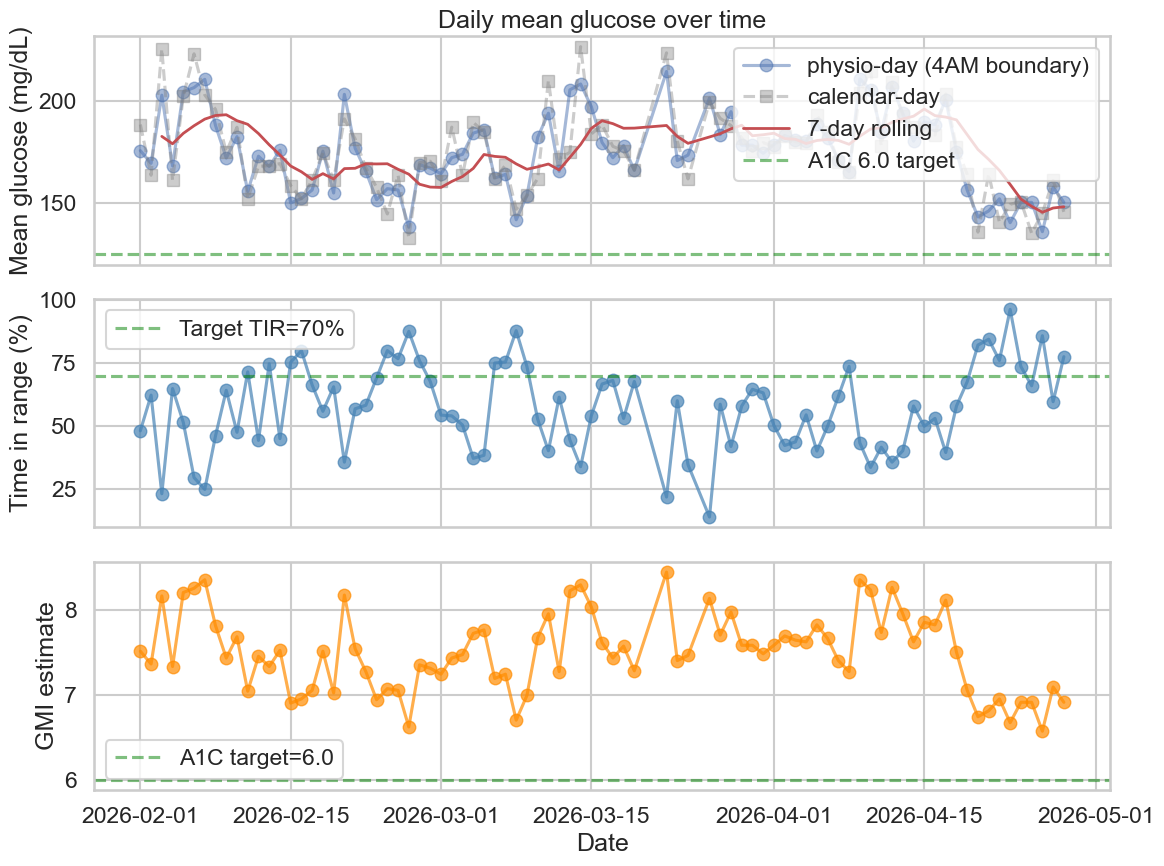

In [54]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].plot(daily['date'], daily['mean_glucose'], 'o-', alpha=0.5, label='physio-day (4AM boundary)')
axes[0].plot(daily['date'], daily['mean_glucose_calendar'], 's--', alpha=0.4, label='calendar-day', color='gray')
axes[0].plot(daily['date'], daily['mean_glucose_7d_avg_descriptive'], 'r-', linewidth=2, label='7-day rolling')
axes[0].axhline(125, color='green', linestyle='--', alpha=0.5, label='A1C 6.0 target')
axes[0].set_ylabel('Mean glucose (mg/dL)')
axes[0].legend(loc='upper right'); axes[0].set_title('Daily mean glucose over time')

axes[1].plot(daily['date'], daily['time_in_range_pct'], 'o-', alpha=0.7, color='steelblue')
axes[1].axhline(70, color='green', linestyle='--', alpha=0.5, label='Target TIR=70%')
axes[1].set_ylabel('Time in range (%)')
axes[1].legend()

axes[2].plot(daily['date'], daily['gmi_estimate'], 'o-', alpha=0.7, color='darkorange')
axes[2].axhline(6.0, color='green', linestyle='--', alpha=0.5, label='A1C target=6.0')
axes[2].set_ylabel('GMI estimate'); axes[2].set_xlabel('Date')
axes[2].legend()
plt.tight_layout(); plt.show()

**Physio vs calendar.** The two means track within ~1 mg/dL of each other on most days because the 4 AM boundary only re-allocates 4 hours of overnight
readings between dates. The difference is largest on Intermittent Fasting (IF) days where the late-evening fast hours move from one date to the next. On initial analysis, it appeared that IF had no significant impact. 

## 3. Per-meal target distribution

`peak_delta` is my primary regression target. The log1p plot shows whether a log transformation will help the linear model.

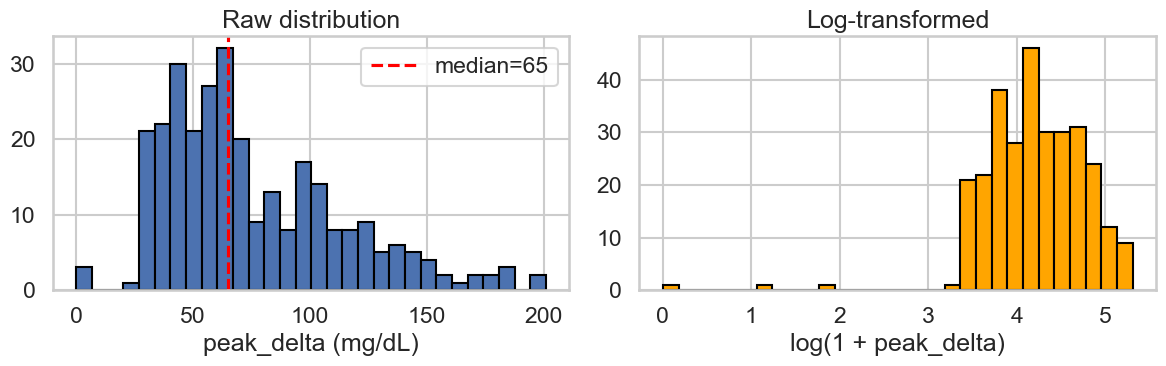

skewness raw: 0.93
skewness log: -1.90


In [55]:
peak_delta = per_meal['peak_delta'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(peak_delta, bins=30, edgecolor='black')
axes[0].set_xlabel('peak_delta (mg/dL)'); axes[0].set_title('Raw distribution')
axes[0].axvline(peak_delta.median(), color='red', linestyle='--',
                label=f'median={peak_delta.median():.0f}')
axes[0].legend()

axes[1].hist(np.log1p(peak_delta), bins=30, edgecolor='black', color='orange')
axes[1].set_xlabel('log(1 + peak_delta)'); axes[1].set_title('Log-transformed')
plt.tight_layout(); plt.show()
print(f"skewness raw: {stats.skew(peak_delta):.2f}")
print(f"skewness log: {stats.skew(np.log1p(peak_delta)):.2f}")

## 4. Carbs (input signal) to peak_delta (outcome)

The textbook relationship: more carbs -> bigger spike. (NOTE: carbs are captured from product nutrition label when available, estimated when missing or averaged if portion size was 1.5 etc)

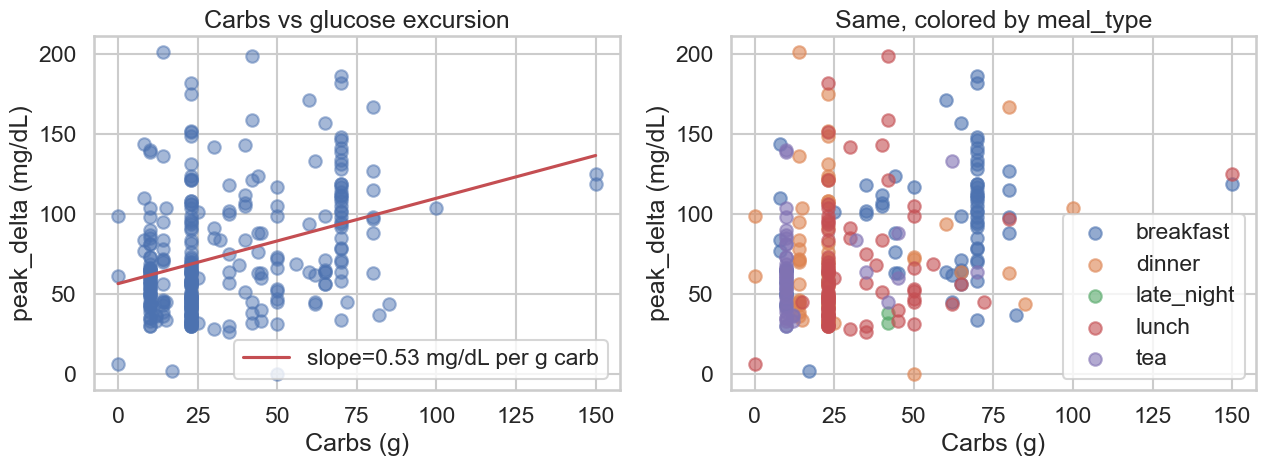

Pearson r = 0.347, p = 1.70e-09, n = 285


In [56]:
sub = per_meal.dropna(subset=['carbs_g_final', 'peak_delta'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(sub['carbs_g_final'], sub['peak_delta'], alpha=0.5)
m, b = np.polyfit(sub['carbs_g_final'], sub['peak_delta'], 1)
xs = np.linspace(sub['carbs_g_final'].min(), sub['carbs_g_final'].max(), 50)
axes[0].plot(xs, m*xs + b, 'r-', label=f'slope={m:.2f} mg/dL per g carb')
axes[0].set_xlabel('Carbs (g)'); axes[0].set_ylabel('peak_delta (mg/dL)')
axes[0].set_title('Carbs vs glucose excursion')
axes[0].legend()

for mt, grp in sub.groupby('meal_type'):
    axes[1].scatter(grp['carbs_g_final'], grp['peak_delta'], label=mt, alpha=0.6)
axes[1].set_xlabel('Carbs (g)'); axes[1].set_ylabel('peak_delta (mg/dL)')
axes[1].set_title('Same, colored by meal_type')
axes[1].legend()
plt.tight_layout(); plt.show()

r, p = stats.pearsonr(sub['carbs_g_final'], sub['peak_delta'])
print(f"Pearson r = {r:.3f}, p = {p:.2e}, n = {len(sub)}")

## 5. Walk effect

The naive comparison is misleading because of selection bias: walks happen *after* meals you anticipate will spike. It maybe a type of `data signal leak` that should be tested by removing from feature. 

In [57]:
per_meal['walked_after'] = (per_meal['walk_min_within_90'] > 0).astype(int)
sub = per_meal.dropna(subset=['peak_delta'])
naive = sub.groupby('walked_after').agg(
    n=('peak_delta', 'count'),
    mean_peak_delta=('peak_delta', 'mean'),
).round(1)
print('=== NAIVE comparison (misleading) ===')
print(naive)

=== NAIVE comparison (misleading) ===
                n  mean_peak_delta
walked_after                      
0             273             74.4
1              22             90.8


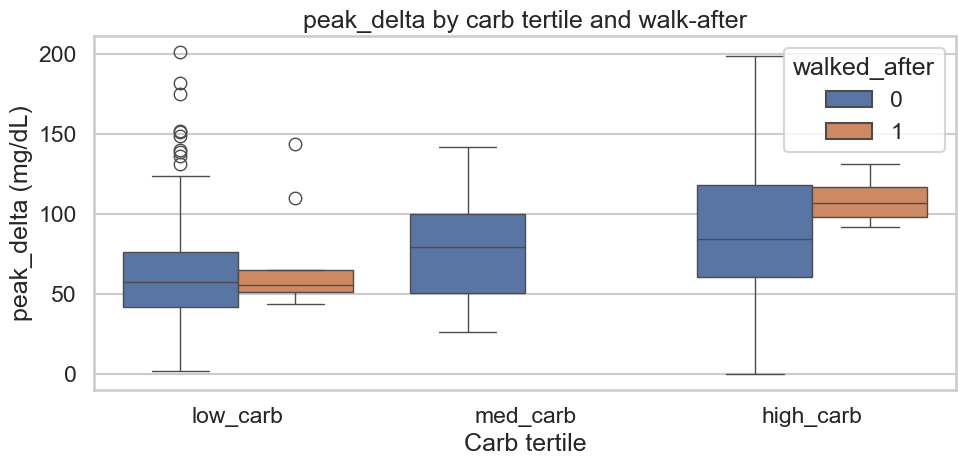

In [58]:
sub2 = sub.dropna(subset=['carbs_g_final']).copy()
sub2['carb_tertile'] = pd.qcut(sub2['carbs_g_final'], 3,
                               labels=['low_carb', 'med_carb', 'high_carb'])

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=sub2, x='carb_tertile', y='peak_delta',
            hue='walked_after', ax=ax)
ax.set_title('peak_delta by carb tertile and walk-after')
ax.set_xlabel('Carb tertile'); ax.set_ylabel('peak_delta (mg/dL)')
plt.tight_layout(); plt.show()

**Watch the n's.** With only ~22 meals followed by a walk, splitting 3 ways
leaves single-digit cells. Goal 1 will need either more walk data going
forward or a regression that uses every meal's row (not just walked ones)
and treats walk minutes as a continuous regressor.

## 6. Per-dish ranking - which meals stabilize vs spike?

Goal 3. Bootstrap 95% CI on mean peak_delta per dish (n >= 3).

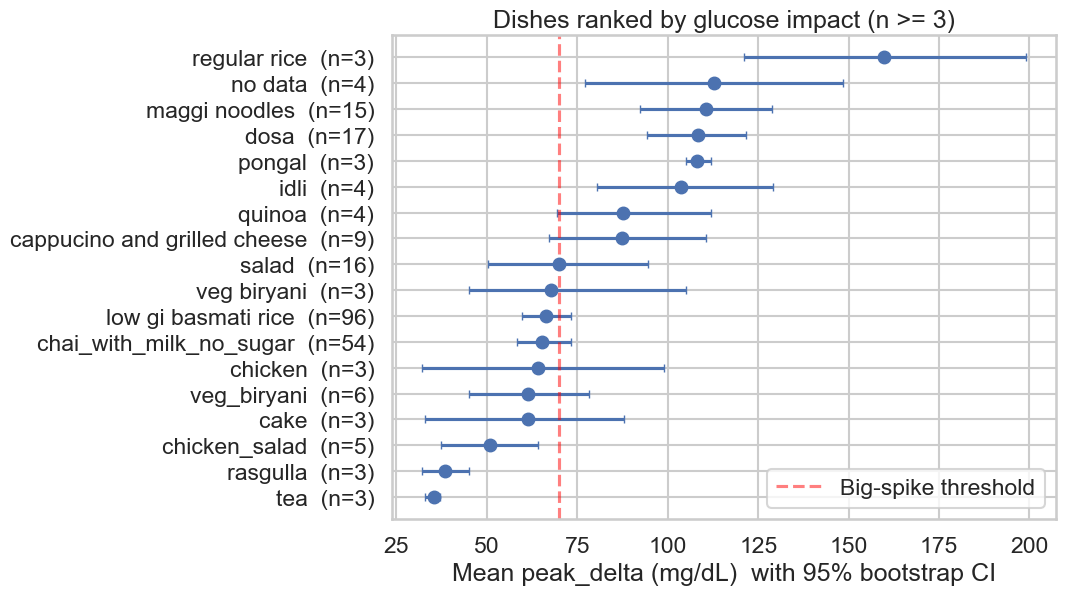

,dish_names,n,mean_peak,median_peak,ci_lo,ci_hi
40,tea,3,35.333333,36.0,33.000000,37.000000
36,rasgulla,3,38.333333,38.0,32.000000,45.000000
13,chicken_salad,5,50.800000,51.0,37.170000,64.200000
2,cake,3,61.333333,63.0,33.000000,88.000000
45,veg_biryani,6,61.333333,59.0,45.000000,78.166667
8,chicken,3,64.000000,61.0,32.000000,99.000000
6,chai_with_milk_no_sugar,54,65.259259,60.0,58.312963,73.130093
26,low gi basmati rice,96,66.208333,56.0,59.644792,73.229427
42,veg biryani,3,67.666667,53.0,45.000000,105.000000
38,salad,16,69.812500,63.0,50.371875,94.439062


In [69]:
def bootstrap_ci(values, n_boot=2000, alpha=0.05):
    rng = np.random.default_rng(42)
    boots = [np.mean(rng.choice(values, size=len(values), replace=True)) for _ in range(n_boot)]
    return np.percentile(boots, [100*alpha/2, 100*(1-alpha/2)])

dish = per_meal.dropna(subset=['peak_delta','dish_names']) \
               .groupby('dish_names') \
               .agg(n=('peak_delta','count'), mean_peak=('peak_delta','mean'), median_peak=('peak_delta','median'), peak_values=('peak_delta', list)).reset_index()

dish[['ci_lo','ci_hi']] = dish['peak_values'].apply(
    lambda v: pd.Series(bootstrap_ci(v)) if len(v) >= 2 else pd.Series([np.nan, np.nan])
)
dish = dish[dish['n'] >= 3].sort_values('mean_peak')

fig, ax = plt.subplots(figsize=(11, max(5, 0.35*len(dish))))
ax.errorbar(dish['mean_peak'], range(len(dish)),
            xerr=[dish['mean_peak'] - dish['ci_lo'],
                  dish['ci_hi'] - dish['mean_peak']],
            fmt='o', capsize=3)
ax.set_yticks(range(len(dish)))
ax.set_yticklabels([f"{d}  (n={n})" for d, n in zip(dish['dish_names'], dish['n'])])
ax.set_xlabel('Mean peak_delta (mg/dL)  with 95% bootstrap CI')
ax.set_title('Dishes ranked by glucose impact (n >= 3)')
ax.axvline(70, color='red', linestyle='--', alpha=0.5, label='Big-spike threshold')
ax.legend()
plt.tight_layout(); plt.show()
display(dish[['dish_names','n','mean_peak','median_peak','ci_lo','ci_hi']])

## 7. Time-of-day & day-of-week patterns

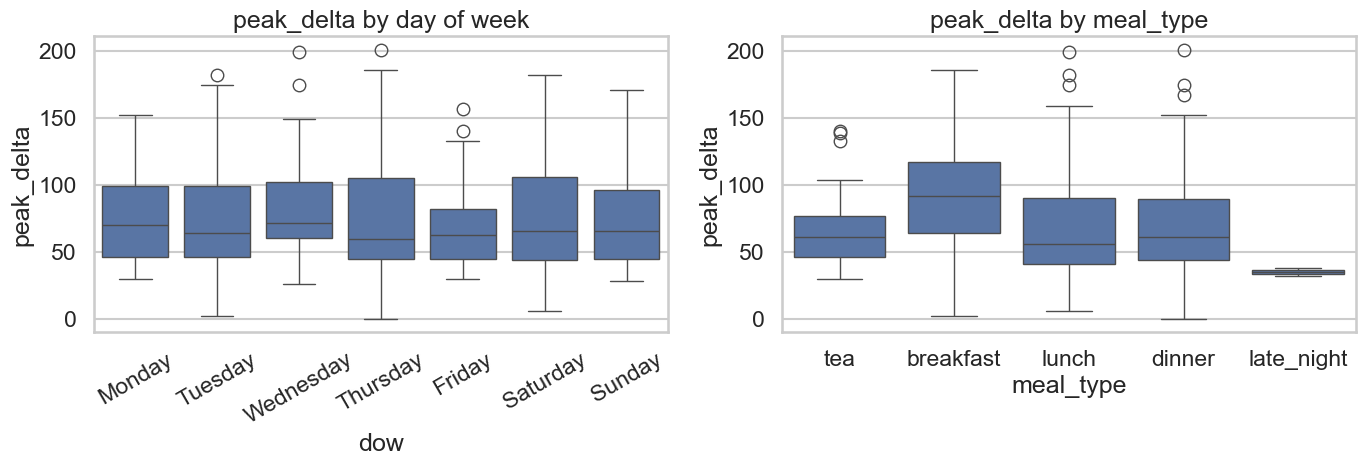

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=per_meal, x='dow', y='peak_delta', order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'], ax=axes[0])
axes[0].set_title('peak_delta by day of week')
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=per_meal, x='meal_type', y='peak_delta', order=['tea','breakfast','lunch','dinner','late_night'], ax=axes[1])
axes[1].set_title('peak_delta by meal_type')
plt.tight_layout(); plt.show()

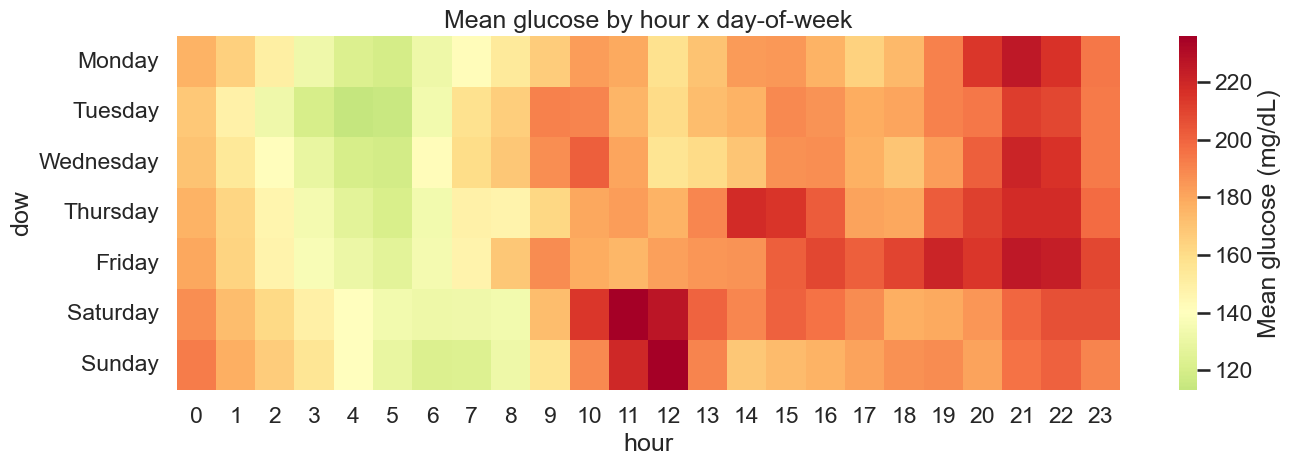

In [61]:
cgm = pd.read_csv(os.path.join(DATA_DIR, '..', 'raw', 'cgm_5min.csv'), parse_dates=['ts'])
cgm['hour'] = cgm['ts'].dt.hour
cgm['dow'] = cgm['ts'].dt.day_name()
heat = cgm.groupby(['dow','hour'])['glucose_mg_dl'].mean().unstack()
heat = heat.reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(heat, cmap='RdYlGn_r', center=140, ax=ax, cbar_kws={'label': 'Mean glucose (mg/dL)'})
ax.set_title('Mean glucose by hour x day-of-week')
plt.tight_layout(); 
plt.show()

## 8. Fasting-window vs feeding-window decomposition

Shifted the question away from "does intermittent fasting help?" on a per-day basis. Instead of comparing calendar IF days vs non-IF days (which is muddled by partial-day fasts straddling midnight), I compare glucose during *actual* fasting hours vs *actual* eating hours, regardless of date.

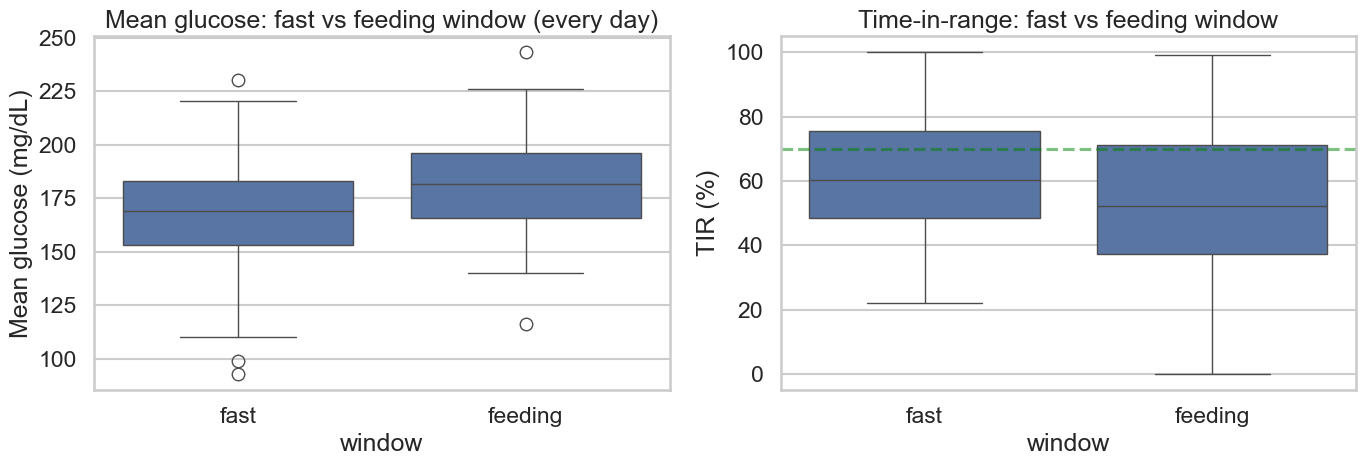

Paired t-test (fasting vs feeding mean glucose, n=83):
  fasting mean    = 167.0
  feeding mean = 181.4
  diff         = +14.4 mg/dL (feeding higher)
  t=-4.53, p=1.99e-05


In [62]:
# All days: fast vs feeding window mean
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Daily-mean comparison
days_clean = daily.dropna(subset=['fast_window_mean_glucose',
                                   'feeding_window_mean_glucose'])
melt_means = pd.melt(days_clean,
                     id_vars=['date'],
                     value_vars=['fast_window_mean_glucose',
                                 'feeding_window_mean_glucose'],
                     var_name='window', value_name='glucose')
melt_means['window'] = melt_means['window'].str.replace(
    '_mean_glucose', '').str.replace('_window', '')
sns.boxplot(data=melt_means, x='window', y='glucose', ax=axes[0])
axes[0].set_title('Mean glucose: fast vs feeding window (every day)')
axes[0].set_ylabel('Mean glucose (mg/dL)')

# TIR comparison
melt_tir = pd.melt(days_clean, id_vars=['date'], value_vars=['fast_window_tir_pct', 'feeding_window_tir_pct'], var_name='window', value_name='tir_pct')
melt_tir['window'] = melt_tir['window'].str.replace('_tir_pct', '').str.replace('_window', '')
sns.boxplot(data=melt_tir, x='window', y='tir_pct', ax=axes[1])
axes[1].set_title('Time-in-range: fast vs feeding window')
axes[1].set_ylabel('TIR (%)')
axes[1].axhline(70, color='green', linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

# Paired t-test
fast_means = days_clean['fast_window_mean_glucose']
feed_means = days_clean['feeding_window_mean_glucose']
t, p = stats.ttest_rel(fast_means, feed_means)
print(f"Paired t-test (fasting vs feeding mean glucose, n={len(days_clean)}):")
print(f"  fasting mean    = {fast_means.mean():.1f}")
print(f"  feeding mean = {feed_means.mean():.1f}")
print(f"  diff         = {feed_means.mean() - fast_means.mean():+.1f} mg/dL " f"(feeding higher)")
print(f"  t={t:.2f}, p={p:.2e}")

## 8b. IF days vs non-IF days : fasting window only

Now compare the *fast-window mean* on IF days vs non-IF days. This isolates "longer fasts give a deeper drop" from "calendar IF day mean" muddle.

C:\Users\anant\AppData\Local\Temp\ipykernel_59580\349246328.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['non-IF', 'IF'])
C:\Users\anant\AppData\Local\Temp\ipykernel_59580\349246328.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['non-IF', 'IF'])


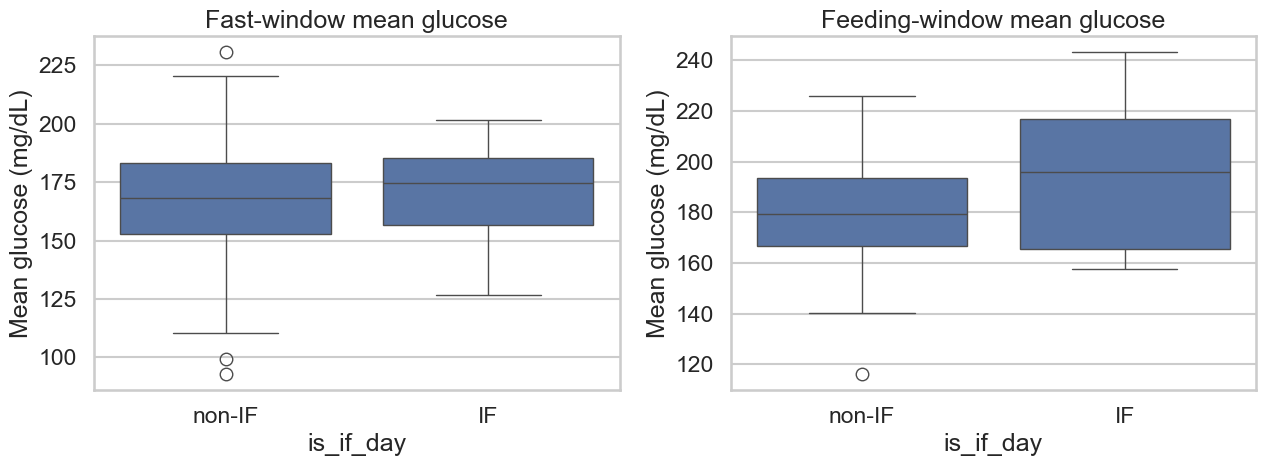

  diff = +3.2 mg/dL,  t=-0.45, p=0.659


In [63]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=daily, x='is_if_day', y='fast_window_mean_glucose', ax=axes[0])
axes[0].set_xticklabels(['non-IF', 'IF'])
axes[0].set_title('Fast-window mean glucose')
axes[0].set_ylabel('Mean glucose (mg/dL)')

sns.boxplot(data=daily, x='is_if_day', y='feeding_window_mean_glucose', ax=axes[1])
axes[1].set_xticklabels(['non-IF', 'IF'])
axes[1].set_title('Feeding-window mean glucose')
axes[1].set_ylabel('Mean glucose (mg/dL)')
plt.tight_layout(); plt.show()

# Stats
g0 = daily.loc[daily['is_if_day']==0, 'fast_window_mean_glucose'].dropna()
g1 = daily.loc[daily['is_if_day']==1, 'fast_window_mean_glucose'].dropna()
t, p = stats.ttest_ind(g0, g1, equal_var=False)

print(f"  diff = {g1.mean() - g0.mean():+.1f} mg/dL,  t={t:.2f}, p={p:.3f}")

**Reading these plots:**

- The first panel (fast vs feeding, all days) is the headline result: my glucose is materially lower during fasted hours regardless of IF status. This is the clearest evidence that fasting itself is doing real work, not just the IF labeling.
- The second pair (IF vs non-IF, holding window type constant) tests whether longer fasts deliver a deeper drop than overnight ones. With only ~14 IF days in the dataset, the confidence intervals are wide and I wouldn't read much into the comparison yet.

## 9. SARIMAX prep - stationarity, ACF, PACF

For the daily mean glucose forecasting model (goal 4). I'm using the **physio-day** mean as the target since it cleanly attributes overnight readings to the right date rather than splitting them across midnight.

In [64]:
y = daily['mean_glucose'].dropna()
adf = adfuller(y, autolag='AIC')
print(f"ADF test on daily mean glucose (physio-day):")
print(f"  statistic = {adf[0]:.3f}, p-value = {adf[1]:.4f}")
print(f"  conclusion: {'STATIONARY' if adf[1] < 0.05 else 'NON-STATIONARY (need differencing)'}")
adf1 = adfuller(y.diff().dropna(), autolag='AIC')
print(f"\nADF on first-differenced series:")
print(f"  p-value = {adf1[1]:.4f}  -> "
      f"{'stationary after d=1' if adf1[1] < 0.05 else 'still non-stationary'}")

ADF test on daily mean glucose (physio-day):
  statistic = -3.263, p-value = 0.0166
  conclusion: STATIONARY

ADF on first-differenced series:
  p-value = 0.0000  -> stationary after d=1


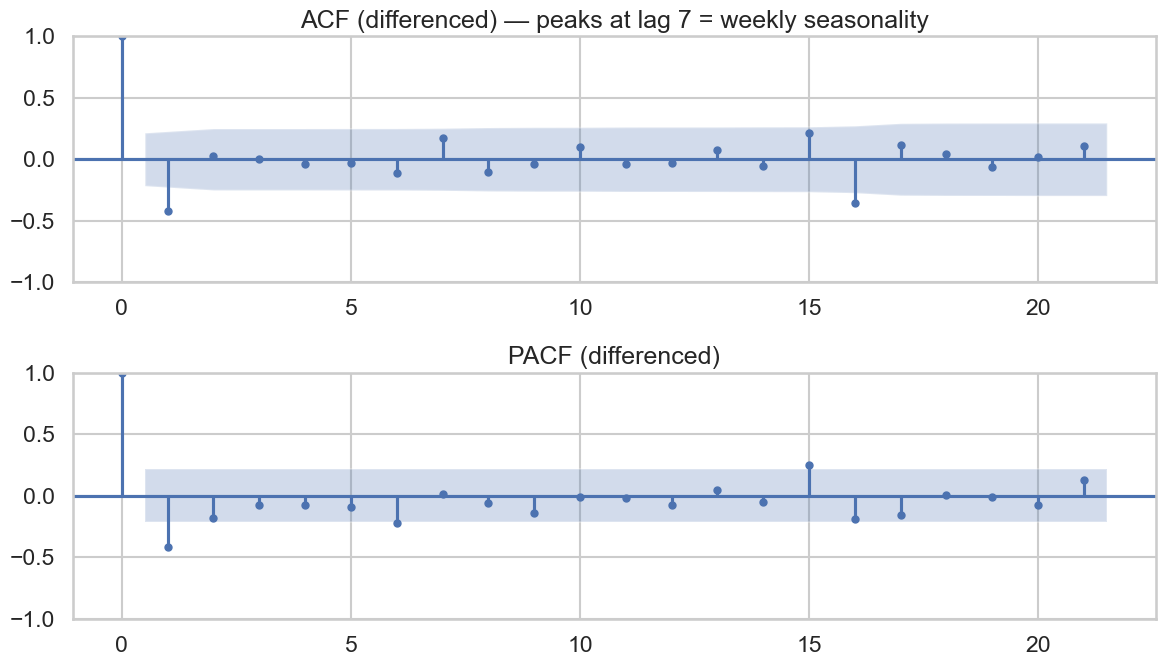

In [65]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7))
plot_acf(y.diff().dropna(), lags=21, ax=axes[0])
axes[0].set_title('ACF (differenced) — peaks at lag 7 = weekly seasonality')
plot_pacf(y.diff().dropna(), lags=21, ax=axes[1], method='ywm')
axes[1].set_title('PACF (differenced)')
plt.tight_layout(); plt.show()

**Reading these for SARIMAX(p,d,q)(P,D,Q,s):**

- The ADF p-value tells me whether `d=0` (already stationary) or `d=1` (needs one difference).
- PACF cuts off at lag → AR order `p`. ACF cuts off at lag → MA order `q`.
- Spikes at lag 7 suggest weekly seasonality, so `s=7` with `(P,D,Q)=(1,0,1)` is a reasonable starting point.

Starting model to fit: **SARIMAX(1,1,1)(1,0,1,7)** with exogenous regressors `[total_walk_min, total_carbs, is_if_day, doses_taken]`.

## 10. Daily-feature correlation matrix

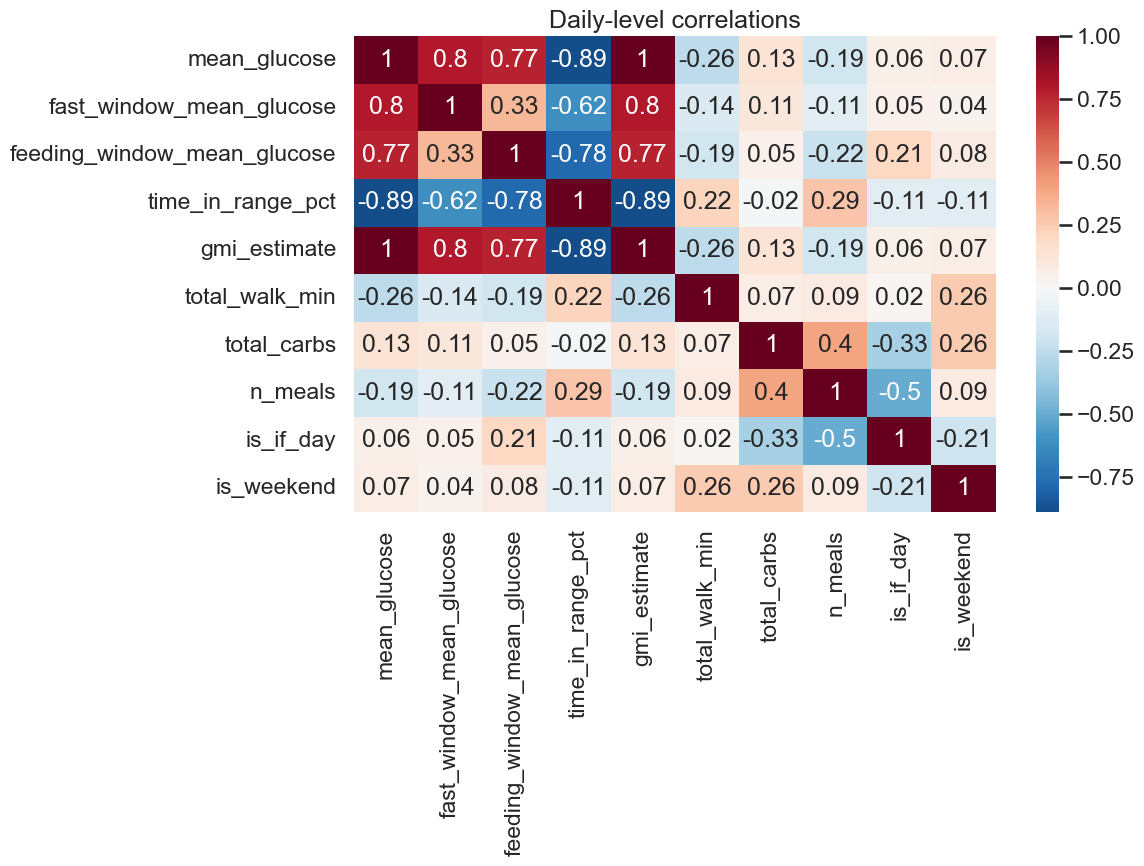

In [66]:
cols = ['mean_glucose', 'fast_window_mean_glucose',
        'feeding_window_mean_glucose', 'time_in_range_pct', 'gmi_estimate',
        'total_walk_min', 'total_carbs', 'n_meals', 'is_if_day', 'is_weekend']
corr = daily[cols].corr().round(2)

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Daily-level correlations')
plt.tight_layout(); plt.show()

## Next steps

1. **Per-meal regression** - start with linear regression.  Hold out the last ~3 weeks as a test set.
2. **Gradient-boosted model** for the same target; compare RMSE; SHAP for importance.
3. **Daily SARIMAX** with seasonality settings inferred above. Try both  `mean_glucose` and `feeding_window_mean_glucose` as targets.
4. **Recommendation layer** - given a predicted high, enumerate intervention candidates (walk 25/45 min, food swap to a low-CI dish) and pick the one with the lowest  predicted peak.